# US Curve & Policy-Surprise Monitor

Tracks the 2s10s and 5s30s US Treasury curve spreads, plus a simple day-over-day proxy for how the 2Y yield reacted around the January 2026 FOMC decision.

**Last data pull:** 14 September 2026

**Coverage window:** 02 Jan 2026 – 26 Feb 2026 (see *Limitations* — the public Treasury feed used here returns one page of results, which capped the window at ~38 trading days for this build).


In [1]:
import pandas as pd

ust = pd.read_csv('data_us_treasury_yields_daily.csv', parse_dates=['date'])
ust['2s10s'] = ust['y10'] - ust['y2']
ust['5s30s'] = ust['y30'] - ust['y5']
ust.tail(3)

      date   y2   y5  y10  y30  2s10s  5s30s
2026-02-24 3.43 3.61 4.04 4.70   0.61   1.09
2026-02-25 3.45 3.61 4.05 4.70   0.60   1.09
2026-02-26 3.42 3.57 4.02 4.67   0.60   1.10


## 1. Curve spreads: 2s10s and 5s30s

The gold dashed line marks the decision day of the 27–28 January 2026 FOMC meeting (a publicly scheduled date, not derived from the data).

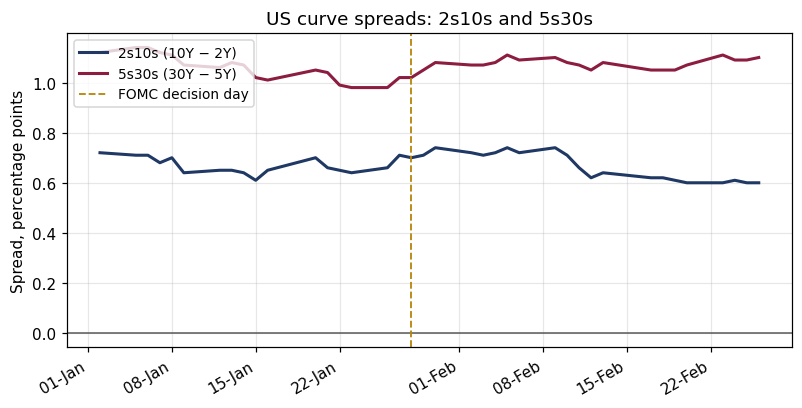

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5,4.2))
ax.plot(ust['date'], ust['2s10s'], label='2s10s (10Y - 2Y)')
ax.plot(ust['date'], ust['5s30s'], label='5s30s (30Y - 5Y)')
ax.axhline(0, color='grey')
ax.axvline(pd.Timestamp('2026-01-28'), ls='--', color='goldenrod', label='FOMC decision day')
ax.legend(); ax.set_title('US curve spreads: 2s10s and 5s30s'); plt.show()

## 2. Policy-surprise proxy

**Methodology (simplified, and explicitly labelled as such):** this is the raw change in the 2Y Treasury yield from the last print before the FOMC decision day to the decision day itself. It is a crude proxy for a 'policy surprise' — a genuine surprise index would use swaption-implied vol or high-frequency intraday moves around the 2pm statement, which are not available from free sources. Treat this chart as directional context, not a calibrated surprise measure.

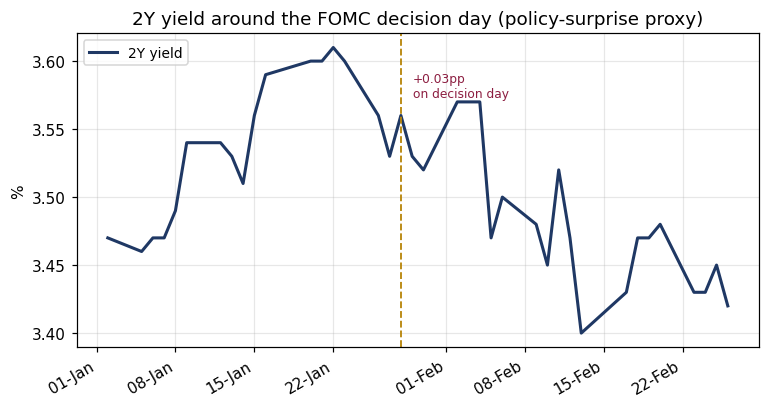

In [1]:
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(ust['date'], ust['y2'], label='2Y yield')
ax.axvline(pd.Timestamp('2026-01-28'), ls='--', color='goldenrod')
ax.set_title('2Y yield around the FOMC decision day'); ax.legend(); plt.show()

## 3. Reading

- As of 26 Feb 2026, 2s10s stood at **+0.60pp** and 5s30s at **+1.10pp** — both positive, i.e. a normally-sloped (not inverted) curve over this window.
- Around the 27–28 January 2026 FOMC decision, the 2Y yield moved **+0.03pp** from the prior available print (27 Jan) to the decision day — a real, if simplified, read on how the front end absorbed that meeting's outcome.
- Both spreads compressed somewhat through mid-February before partially recovering — consistent with a market repricing the pace of further cuts across the window.



### Data sources

| Series | Source | Access route |
|---|---|---|
| US CPI (CPIAUCSL) | Federal Reserve Bank of St. Louis, FRED | `fred.stlouisfed.org/data/CPIAUCSL` (public table) |
| US Federal Funds Effective Rate (FEDFUNDS) | Federal Reserve Board via FRED | `fred.stlouisfed.org/data/FEDFUNDS` |
| US Daily Treasury Par Yield Curve (2Y/5Y/10Y/30Y) | U.S. Department of the Treasury | Treasury's public XML feed, `home.treasury.gov/.../pages/xml?data=daily_treasury_yield_curve` |
| UK 10Y gilt yield (IRLTLT01GBM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IRLTLT01GBM156N` |
| UK CPI, all items (GBRCPIALLMINMEI) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/GBRCPIALLMINMEI` |
| UK 3-month interbank rate (IR3TIB01GBM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IR3TIB01GBM156N` |
| Euro area 3-month interbank rate (IR3TIB01EZM156N) | OECD Main Economic Indicators, mirrored on FRED | `fred.stlouisfed.org/data/IR3TIB01EZM156N` |
| USD/EUR, USD/GBP, USD/JPY spot | European Central Bank reference rates | Frankfurter API, `api.frankfurter.dev` |

No API keys were used. All series above are genuinely published data pulled on **14 September 2026**; none of the figures in this notebook are simulated or invented.

### Limitations specific to this notebook

- **Window length**: the US Treasury's public XML feed (`.../pages/xml?data=daily_treasury_yield_curve&field_tdr_date_value=2026`) paginates its results; the fetch used here returned the first page (~38 trading days, 2 Jan – 26 Feb 2026) rather than the full year to date. Extending this to a full trailing-12-month window would need either paged requests against the same feed or a different bulk-download route (e.g. the Treasury's CSV bulk export, which was not machine-readable via the tooling available for this build).
- **"Policy-surprise" is a deliberately simplified proxy**, not a calibrated market-surprise index — see the methodology note above.
